In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/clean/cleaned_customer_support_1000.csv")

In [3]:
df.head()

,ticket_id,ticket,category,priority,ticket_length
0,1,I cannot receive verification codes after chan...,Account,High,153
1,2,I think someone else accessed my account. I fi...,Account,High,109
2,3,The app shows a blank screen after the update....,Technical,High,114
3,4,The checkout button is not responding. I first...,Technical,High,106
4,5,I was charged in the wrong currency. I first n...,Billing,Medium,106


In [7]:
df["category"].value_counts()

category
Technical    310
Billing      245
Delivery     190
Account      155
Refund       100
Name: count, dtype: int64

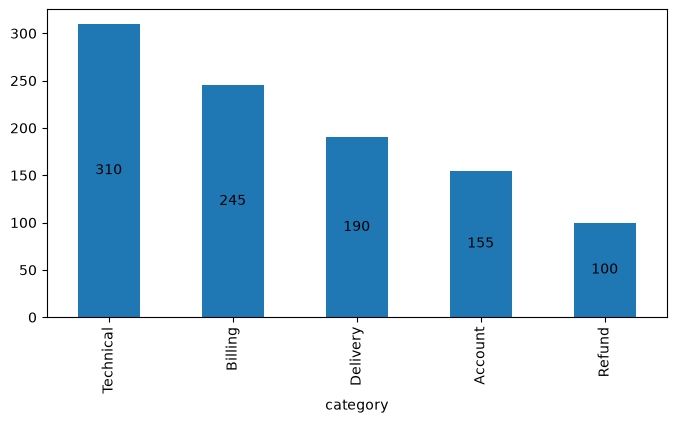

In [15]:
category_count = df["category"].value_counts()

bar = category_count.plot(kind="bar", figsize=(8,4))
for container in bar.containers:
    bar.bar_label(container, label_type="center")

In [16]:
# It is clear that Technical is the most common category

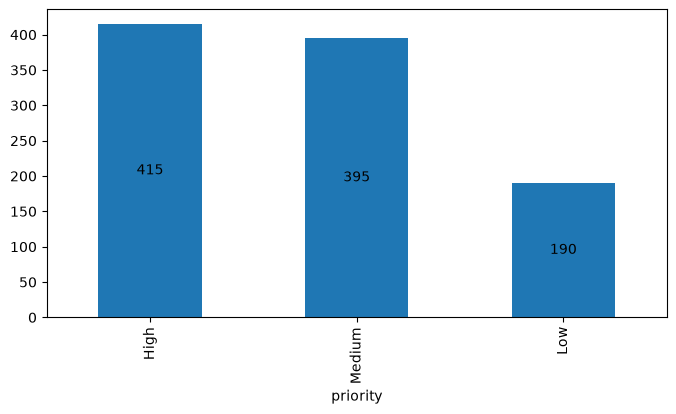

In [18]:
priority_count = df["priority"].value_counts()

bar = priority_count.plot(kind="bar", figsize=(8,4))
for container in bar.containers:
    bar.bar_label(container, label_type="center")

In [19]:
pd.crosstab(df["category"], df["priority"])

priority,High,Low,Medium
category,,,
Account,55,35,65
Billing,105,45,95
Delivery,75,35,80
Refund,30,25,45
Technical,150,50,110


In [21]:
# Once again, you can cleary see that the Technical category has the most "high priority" tickets per category

In [23]:
import sqlite3
link = sqlite3.connect(":memory:")
df.to_sql("tickets", link, index=False, if_exists="replace")

1000

In [25]:
query = """
SELECT category, COUNT(*) AS ticket_count
FROM tickets
GROUP BY category
"""

pd.read_sql_query(query, link)

,category,ticket_count
0,Account,155
1,Billing,245
2,Delivery,190
3,Refund,100
4,Technical,310


In [26]:
query = """
SELECT category, AVG(ticket_length) AS average_length
FROM tickets
GROUP BY category
ORDER by average_length DESC;
"""

pd.read_sql_query(query, link)

,category,average_length
0,Billing,120.334694
1,Refund,118.490000
2,Technical,118.206452
3,Delivery,115.357895
4,Account,114.670968


In [27]:
query = """
SELECT category, ticket, priority
FROM tickets
WHERE priority ="High";
"""

pd.read_sql_query(query, link)

,category,ticket,priority
0,Account,I cannot receive verification codes after chan...,High
1,Account,I think someone else accessed my account. I fi...,High
2,Technical,The app shows a blank screen after the update....,High
3,Technical,The checkout button is not responding. I first...,High
4,Account,I cannot receive verification codes after chan...,High
...,...,...,...
410,Technical,The checkout button is not responding. I first...,High
411,Technical,I get an error every time I upload a file. I f...,High
412,Technical,The application freezes when I submit the form...,High
413,Account,Someone changed my account email without permi...,High
